# Mapping green spaces in Exeter

## Project Overview
This project analyses green space availability across the 2022 wards of Exeter. Using a GeoPackage of ward boundaries and a Census 2021 population dataset (TS001), I calculated green‑space‑per‑capita to explore how access to green areas varies across the city.

## Data Sources
- Ward boundaries: 2022 wards from the UK Government Open Geography Portal
- Population: Census 2021, Table TS001 (Number of usual residents)

## Method Summary
- Loaded and cleaned the ward boundary dataset
- Calculated green‑space area for each ward
- Downloaded population counts for all 13 Exeter wards
- Merged population data with spatial data
- Computed green‑space‑per‑person
- Visualised results using choropleth mapping

## Key Aim
Identify which wards have the highest and lowest green‑space‑per‑capita and highlight spatial inequalities within Exeter.

## 1. Importing required libraries

In this section I import all the Python libraries used throughout the analysis.
These include:
- geopandas - the core library for working with geographic data, extending pandas with geometry support
- matplotlib for plotting
- osmnx for accessing OpenStreetMap data
- pandas / numpy for general data manipulation
- folium for interactive mapping
- scipy for the kernel density estimation used in the heatmap
- mapclassify for improved choropleth classification
- requests and io for fetching population data from the nomis API

These imports set up the environment for loading, processing, and visualising Exeter’s ward‑level geospatial data.

In [ ]:
import io
import textwrap

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import osmnx as ox
import pandas as pd
import requests
import mapclassify as mc
from IPython.display import display

import matplotlib.patheffects as PathEffects
from matplotlib.patches import Polygon
import numpy as np
from scipy.stats import gaussian_kde
import folium
from folium.plugins import HeatMap

## 2. Loading Exeter ward boundaries

The ward boundaries are loaded directly from the UK Government's ArcGIS FeatureServer, which hosts the official ONS ward boundary dataset.
The query filters to Exeter only using the LAD25NM (Local Authority District name) field, to avoid using the entire UK dataset.

The code attempts to load the data from the online service first.
If the request fails (e.g., no internet connection), it automatically falls back to a local GeoPackage copy.
This ensures the notebook remains reproducible even offline.

In [ ]:
url = (
    "https://services1.arcgis.com/ESMARspQHYMw9BZ9/ArcGIS/rest/services/"
    "WD_MAY_2025_UK_BFC_V2/FeatureServer/0/query?"
    "where=LAD25NM%3D%27Exeter%27&outFields=*&outSR=4326&f=geojson"
)
try:
    neighbourhoods = gpd.read_file(url)
    print("Loaded Exeter wards from ArcGIS FeatureServer.")
except Exception as e:
    print(f"Could not load from service: {e}. Falling back to local GeoPackage.")
    try:
        neighbourhoods = gpd.read_file("WD_MAY_2025_UK_BFC_V2_-5185687143062460842.gpkg")
        print("Loaded local GeoPackage.")
    except FileNotFoundError as e:
        print(f"Local file not found: {e}")

Loaded Exeter wards from ArcGIS FeatureServer.


## 3. Inspecting the data

Before doing any mapping, it's worth looking at the raw data to understand its structure.

Key columns:
- **LONG and LAT (longitude and latitude):** These are the coordinates of the label point: a point pre-calculated by the ONS specifically for cartographic purposes, chosen to be a good place to put a text label on a map. It's guaranteed to fall inside the polygon, unlike a centroid, which can fall outside irregular or concave shapes.
- **Shape_Area:** The total area of the ward polygon in the units of whatever CRS the data was stored in on the server, in this case, m^2.
- **Shape_Length**: The perimeter of the ward polygon (i.e. the total length of the boundary).
- **geometry**: a polygon or multipolygon; a list of hundreds of coordinate pairs tracing around the ward boundary, stored by GeoPandas using Shapely under the hood. I'm using the BFC (full clipped) version of the dataset, which is the highest level of data that the ONS publishes.

In [ ]:
# scrollable table of data
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
neighbourhoods

,FID,WD25CD,WD25NM,WD25NMW,LAD25CD,LAD25NM,LAD25NMW,BNG_E,BNG_N,LONG,LAT,Shape__Area,Shape__Length,GlobalID,geometry
0,2073,E05011011,Alphington,,E07000041,Exeter,,292041,90375,-3.530173,50.702950,5.663131e+06,14165.415026,ecdd2f82-26b4-46e4-8a25-0e3ad91c4d8c,"POLYGON ((-3.536 50.71482, -3.53599 50.71481, ..."
1,2074,E05011012,Duryard and St James,,E07000041,Exeter,,291818,94691,-3.534597,50.741708,4.546631e+06,11495.765556,fdecb6e0-c965-455b-9a17-0f686626ef52,"POLYGON ((-3.52905 50.75656, -3.5291 50.75652,..."
2,2075,E05011013,Exwick,,E07000041,Exeter,,290400,93605,-3.554362,50.731679,4.167384e+06,12231.201285,c528538b-2d28-4883-b2f7-84eec501f746,"POLYGON ((-3.55203 50.74513, -3.55204 50.74511..."
3,2076,E05011014,Heavitree,,E07000041,Exeter,,294076,92735,-3.502044,50.724540,1.674969e+06,6495.959110,ab302750-d84a-43b1-b050-40887582d88b,"POLYGON ((-3.48937 50.72785, -3.4895 50.72768,..."
4,2077,E05011015,Mincinglake and Whipton,,E07000041,Exeter,,294476,94678,-3.496936,50.742080,3.948375e+06,11442.999942,91054b18-cdcb-4ae5-ba8a-a7c7ea77c677,"POLYGON ((-3.48822 50.75214, -3.48819 50.75212..."
5,2078,E05011016,Newtown and St Leonard's,,E07000041,Exeter,,292880,92502,-3.518914,50.722226,1.741477e+06,6446.707758,6054a315-f1db-4027-83e0-52b1ccb57098,"POLYGON ((-3.51341 50.72846, -3.51335 50.72822..."
6,2079,E05011017,Pennsylvania,,E07000041,Exeter,,293026,95212,-3.517634,50.746615,4.398151e+06,13213.387443,08d0019e-54d5-4316-b8f7-9e9b44730cf6,"POLYGON ((-3.50275 50.75527, -3.50279 50.75521..."
7,2080,E05011018,Pinhoe,,E07000041,Exeter,,295871,93845,-3.476936,50.734844,3.789502e+06,10431.716569,0eb324f5-4aff-41f4-ab8d-2cac43404ff9,"POLYGON ((-3.46244 50.72882, -3.46303 50.72878..."
8,2081,E05011019,Priory,,E07000041,Exeter,,294135,90953,-3.500696,50.708531,3.455320e+06,11871.951218,6c4146b3-8855-4cdc-b16a-d37192e945f7,"MULTIPOLYGON (((-3.49904 50.69629, -3.49904 50..."
9,2082,E05011020,St David's,,E07000041,Exeter,,292096,92237,-3.529939,50.719699,2.483900e+06,9169.217598,a1ba2e23-7a24-45fd-9b18-6963dc455080,"POLYGON ((-3.52695 50.72556, -3.52692 50.72553..."


## 4. Interactive Map of Ward Boundaries

Using the .explore() method is a quick way to render a map and visually check that the data has been loaded correctly.

In [ ]:
# interactive map of neighbourhoods
neighbourhoods.explore()

## 5. Helper Functions 

These two functions prevent repeated code across multiple cells, when plotting maps / graphs later on:
- add_ward_labels() annotates each ward polygon with its name, placed at the representative point (a point guaranteed to be inside the polygon). It wraps long names to avoid overlap.
- plot_bar() produces a horizontal bar chart comparing wards, which I'll use alongside each choropleth map for easier reading of exact values.

In [ ]:
# helper function: add ward name labels to a choropleth map
def add_ward_labels(ax, gdf, col="WD25NM", width=14, fontsize=7):
    for _, row in gdf.iterrows():
        point = row.geometry.representative_point()
        label = "\n".join(textwrap.wrap(row[col], width=width))
        ax.annotate(
            text=label,
            xy=(point.x, point.y),
            horizontalalignment="center",
            fontsize=fontsize,
            color="black",
            weight="bold",
            alpha=0.9,
            bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none", "boxstyle": "round,pad=0.2"},
            zorder=5,
        )

# helper function: horizontal bar chart for ward comparisons
def plot_bar(gdf, col, xlabel, title):
    bar_df = gdf.sort_values(col, ascending=False)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(bar_df["WD25NM"], bar_df[col], color="seagreen", edgecolor="black")
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 6. Downloading Raw OSM Data

Before deciding on a filter, I'm downloading everything tagged landuse or leisure in Exeter to see what values are actually present. OpenStreetMap uses a tag system of key=value pairs. Passing True for a key returns all features with any value for that key.

This gives me a wide variety of tags to explore before narrowing down. The output shows every distinct tag value that appears in the data, along with how many features have that value.

In [ ]:
keys = ["landuse", "leisure"]
gdf = ox.features_from_place("Exeter, UK", tags={k: True for k in keys})

# explore what tag values are present in the raw OSM download
for key in ["landuse", "leisure"]:
    if key in gdf.columns:
        print(f"\n--- {key} values ---")
        print(gdf[key].value_counts(dropna=True).to_string())


--- landuse values ---
landuse
grass                674
residential          446
retail                85
commercial            71
construction          47
farmland              45
recreation_ground     38
industrial            30
meadow                27
allotments            26
railway               25
forest                20
religious             12
cemetery              11
orchard                9
brownfield             5
farmyard               5
greenfield             5
paddock                3
highway                3
military               1
village_green          1
quarry                 1
depot                  1
aquaculture            1
flowerbed              1

--- leisure values ---
leisure
pitch                  151
park                   132
playground              86
garden                  58
sports_centre           20
fitness_centre          19
picnic_table            15
swimming_pool           11
bird_hide                8
nature_reserve           8
track           

## 7. Choosing Tags for Green Space

Based on the exploration above, I filtered to:
- leisure=park — managed public parks open to all
- leisure=garden — public gardens, typically smaller and more formal than parks
- landuse=grass — open grassland, which captures green spaces that aren't formally designated as parks or gardens

I excluded:
- leisure=playground — too small to be meaningful at ward scale, and typically just a small feature within a larger park
- landuse=allotments — privately rented plots, not publicly accessible green space
- landuse=meadow — too context-dependent; in OSM this often refers to agricultural land rather than accessible green space

These are judgement calls, and a different researcher might make different choices depending on their definition of "green space". The tag exploration in the previous cell is what made it possible to make these decisions consciously rather than arbitrarily.

In [ ]:
green = ox.features_from_place(
    "Exeter, UK",
    tags={"leisure": ["park", "garden"], "landuse": "grass"}
)

## 8. Reprojecting to a Consistent CRS

Both GeoDataFrames need to be in the same coordinate reference system (CRS) before any spatial analysis can be done. I'm reprojecting to EPSG:3857 (Web Mercator), which expresses coordinates in metres rather than degrees.
This matters for two reasons. First, gpd.overlay requires both inputs to be in the same CRS. Second, and more importantly, calculating area in degrees gives meaningless results: a degree of longitude is a different physical distance depending on latitude. Working in metres means geometry.area returns actual square metres.
I'm also removing any null geometries from the green space GeoDataFrame, which can occasionally appear in OSM data where a feature has tags but no geometry attached.

In [ ]:
neighbourhoods = neighbourhoods.to_crs(3857)
green = green.to_crs(3857)
green = green[green.geometry.notnull()]

## 9. Clipping Green Spaces to Ward Boundaries

Before I can analyse green space by ward, I need to handle a geographical issue: green spaces might sit across the border between multiple wards.

There are two naive approaches that would both give wrong answers:
1. count the whole green area in whichever ward it overlaps with: this double-counts the area, inflating the totals for both wards
2. count the whole green area in whichever ward its centre falls: this assigns all the area to one ward and none to the other, which is also wrong

The best approach, therefore, is to physically cut each green space polygon along the ward boundaries, producing new, smaller polygons that each sit entirely within one ward. This is done using gpd.overlay with how="intersection". Each piece is then only counted once, in the ward it falls within.

After the intersection, I calculate the area of each resulting polygon in square metres using geometry.area.


In [ ]:
# clip green spaces to ward boundaries so that shared green polygons are not counted more than once
joined = gpd.overlay(green, neighbourhoods, how="intersection")
joined["area_m2"] = joined.geometry.area

## 10. Summarising Green Space by Ward

Now, I can sum the green space area for each ward by grouping on the ward name column WD25NM. I'm keeping both the raw area in m^2 (used for percentage calculations later) and a converted value in km^2 (used for display).

After merging the summary back onto the neighbourhoods GeoDataFrame, I filter to Exeter only. Note the .copy() when creating exeter. This is important because exeter is a filtered slice of neighbourhoods, and without .copy() any mutations (like adding new columns) could fail silently.

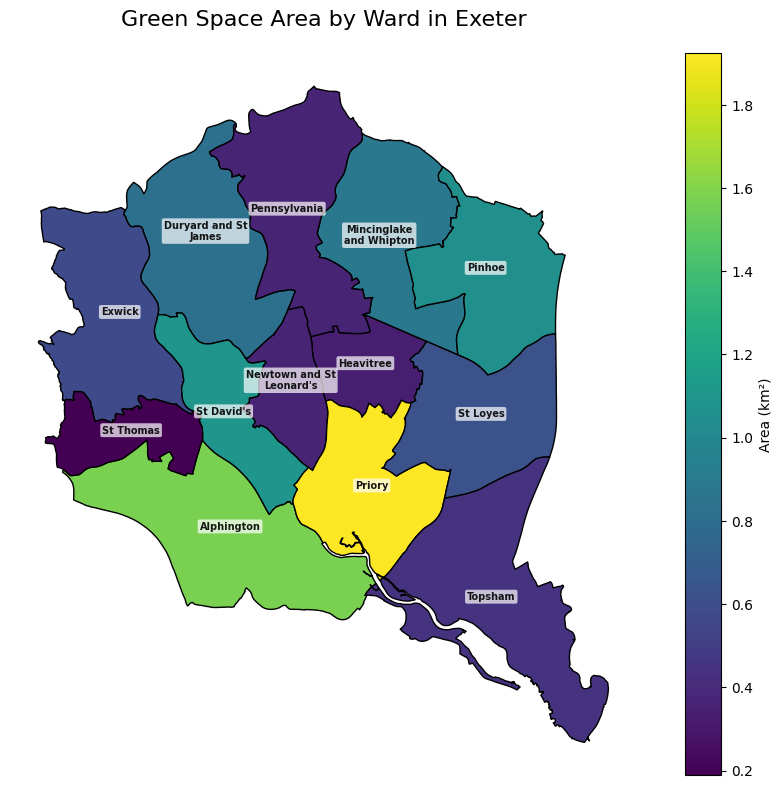

In [ ]:
# sum green space area per ward
summary = joined.groupby("WD25NM")["area_m2"].sum().reset_index()

# keep both m² (for percentage calculations) and km² (for display)
summary["area_km2"] = summary["area_m2"] / 1_000_000

# merge back into neighbourhoods, then filter to Exeter only
neighbourhoods = neighbourhoods.merge(summary[["WD25NM", "area_m2", "area_km2"]], on="WD25NM", how="left")
exeter = neighbourhoods[neighbourhoods["LAD25NM"] == "Exeter"].copy()


## 11. Mapping Absolute Green Space Area by Ward

The simplest question is how much green space each ward contains in total. Each ward polygon is coloured by its total green space area in km^2, with dark purple indicating the least green space and yellow the most. Ward names are placed at each polygon's representative point (a point guaranteeed to fall inside the polygon, unlike the centroid which can fall outside irregular shapes).

In [ ]:
# choropleth: absolute green space area by ward
ax = exeter.plot(
    column="area_km2",
    cmap="viridis",
    legend=True,
    legend_kwds={"label": "Area (km²)"},
    figsize=(10, 8),
    edgecolor="black",
)
add_ward_labels(ax, exeter)
ax.set_title("Green Space Area by Ward in Exeter", fontsize=16, pad=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 12. Normalising by Ward Size

Raw area isn't a fair comparison between wards, because some wards cover much more land than others. A large ward will naturally tend to contain more green space simply because it's bigger.

Expressing green space as a percentage of total ward area gives a more meaningful comparison: it answers "how green is this ward?" rather than "how big is the green space in this ward?". I calculate ward area from the geometry directly, since the data is already in EPSG:3857 and geometry.area returns accurate m² values.

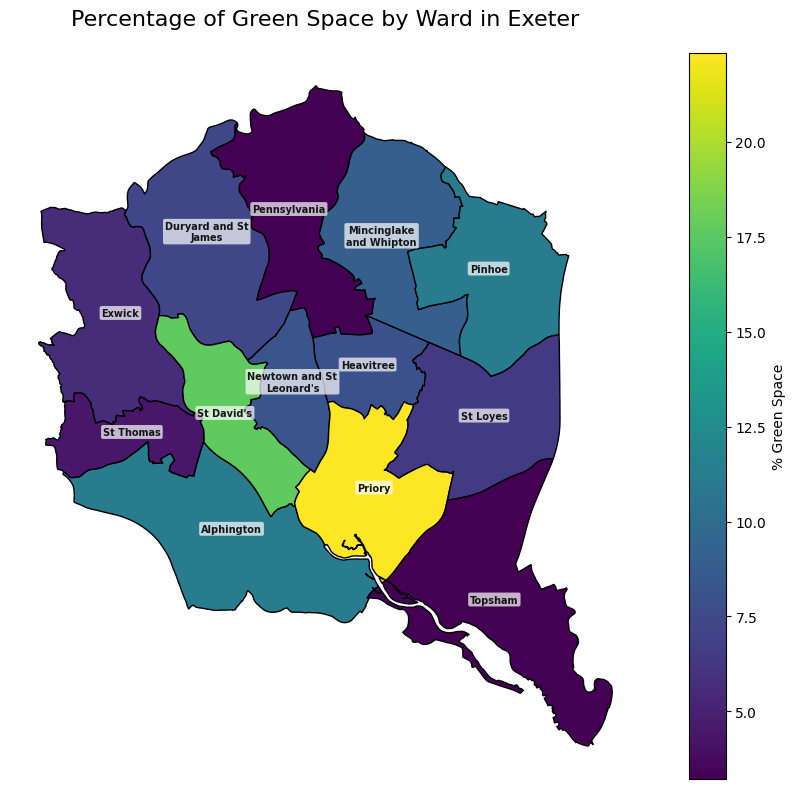

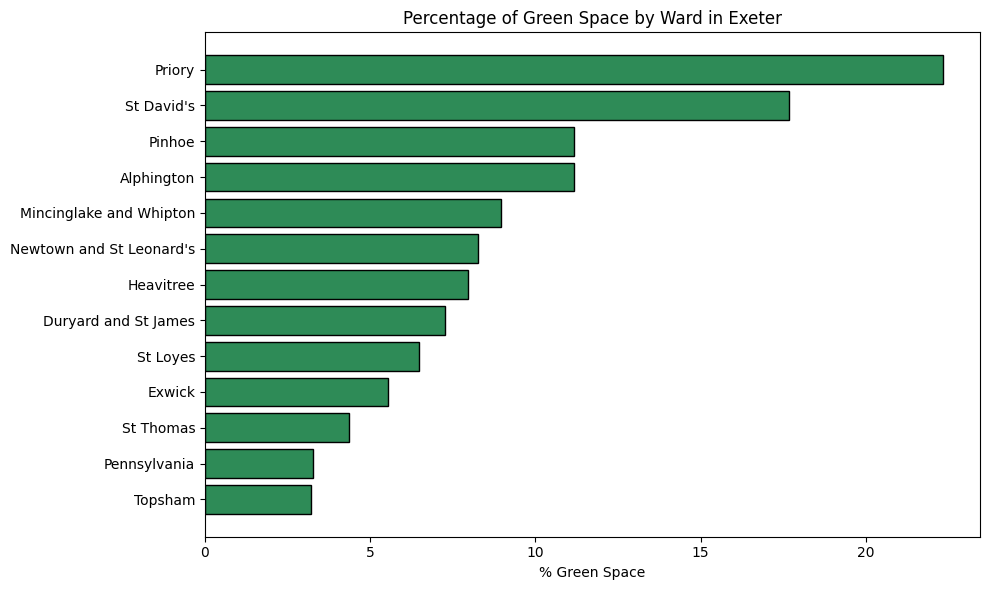

In [ ]:
# normalise by ward area to get percentage green space
exeter["ward_area_m2"] = exeter.geometry.area
exeter["pct_green"] = (exeter["area_m2"] / exeter["ward_area_m2"]) * 100

(add description here)

In [ ]:
# choropleth: percentage green space by ward
ax = exeter.plot(
    column="pct_green",
    cmap="viridis",
    legend=True,
    legend_kwds={"label": "% Green Space"},
    figsize=(10, 8),
    edgecolor="black",
)
add_ward_labels(ax, exeter)
ax.set_title("Percentage of Green Space by Ward in Exeter", fontsize=16, pad=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

plot_bar(exeter, "pct_green", "% Green Space", "Percentage of Green Space by Ward in Exeter")

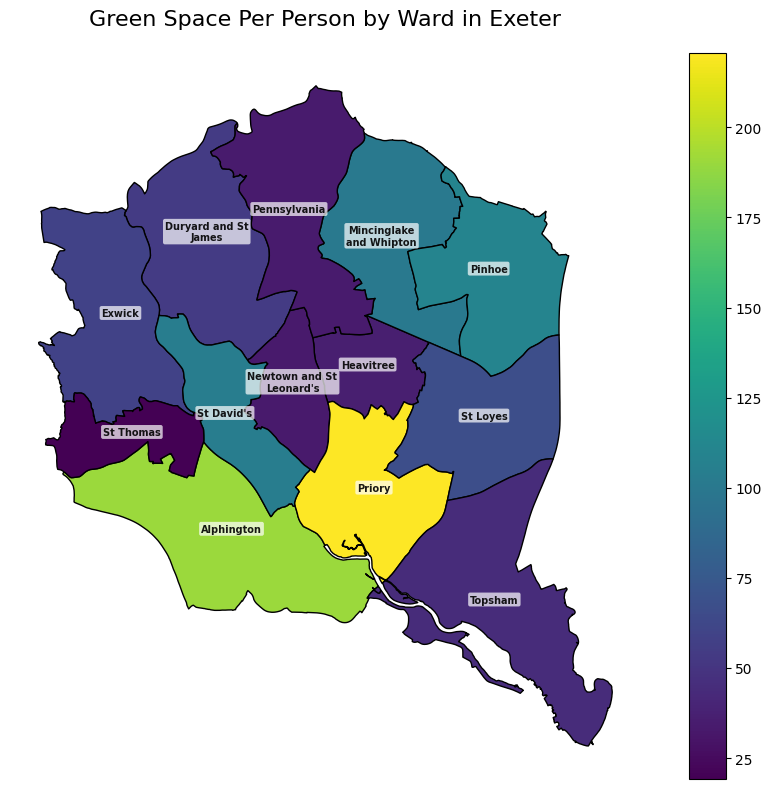

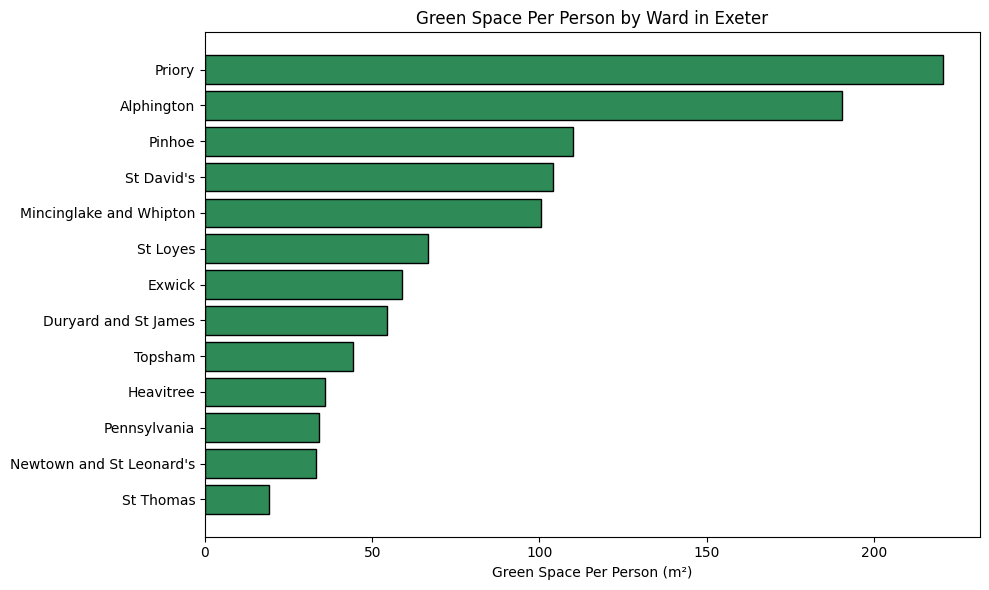

In [ ]:
URL = "https://www.nomisweb.co.uk/api/v01/dataset/NM_2021_1.data.csv"
params = {
    "geography": "E07000041TYPE153",  # Exeter wards (2022 ward geography)
    "time": "2021",
    "c2021_restype_3": "0",  # Total: All usual residents
    "measures": "20100",  # Persons Value
    "select": "geography_name,obs_value",
    "recordlimit": "50",
}

r = requests.get(URL, params=params)
r.raise_for_status()

df = pd.read_csv(io.StringIO(r.text))
df.columns = df.columns.str.lower()
df = df.rename(columns={"geography_name": "ward_name", "obs_value": "population"})
df["ward_name"] = df["ward_name"].str.replace(r" \(Exeter\)$", "", regex=True)
df = df.sort_values("ward_name")

# merge onto exeter GeoDataFrame using the ward name column, and check for any unmatched wards
exeter = exeter.merge(df, left_on="WD25NM", right_on="ward_name", how="left")
missing = exeter[exeter["population"].isna()]
if not missing.empty:
    print("Missing population for wards:", missing["WD25NM"].tolist())

# calculate green space per capita
exeter["green_per_person"] = exeter["area_m2"] / exeter["population"]

# plotting
ax = exeter.plot(
    column="green_per_person",
    cmap="viridis",
    legend=True,
    figsize=(10, 8),
    edgecolor="black",
)


add_ward_labels(ax, exeter)
ax.set_title("Green Space Per Person by Ward in Exeter", fontsize=16, pad=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

plot_bar(exeter, "green_per_person", "Green Space Per Person (m²)", "Green Space Per Person by Ward in Exeter")

# Improving the Cloropleth Classification

Looking at the maps above, most wards appear bunched in the lower colour bands. This is a sign that the default equal-interval classification is being skewed by one or two outlier wards with much more green space than the rest. The colour variation doesn't reflect the real spread in the data.

To fix this, I'll switch to Jenks natural breaks classification, using the mapclassify library I'd already imported. This algorithm finds class boundaries where the data naturally clusters, so the colour bands better reflect genuine differences between wards. It also switches from a continuous colorbar to a discrete legend, which is easier to interpret.

## How Jenks natural breaks works

The algorithm looks at the ward values nd tries to find the "gaps" in the data: points where there's a natural jump between one group of values and the next. 

With k = 5, you're asking it to find 5 such clusters. Each cluster gets one colour from the viridis scale:
Dark purple — wards in the lowest cluster (least green space)
Blue/teal — wards in the second cluster
Green — wards in the middle cluster
Yellow-green — wards in the fourth cluster
Yellow — wards in the highest cluster (most green space)

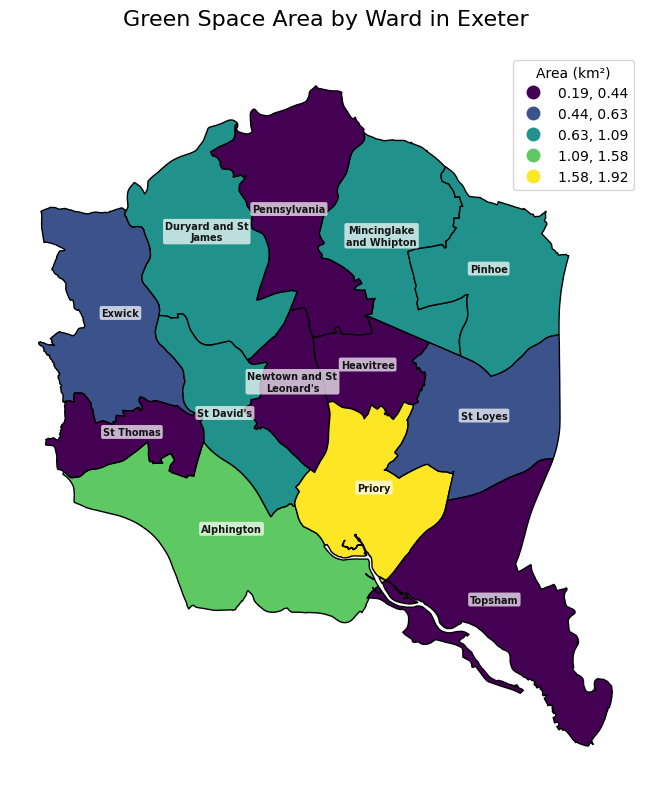

In [ ]:
# choropleth: absolute green space area by ward (natural breaks)
ax = exeter.plot(
    column="area_km2",
    scheme="natural_breaks",
    k=5,
    cmap="viridis",
    legend=True,
    legend_kwds={"title": "Area (km²)", "fmt": "{:.2f}"},
    figsize=(10, 8),
    edgecolor="black",
)
add_ward_labels(ax, exeter)
ax.set_title("Green Space Area by Ward in Exeter", fontsize=16, pad=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

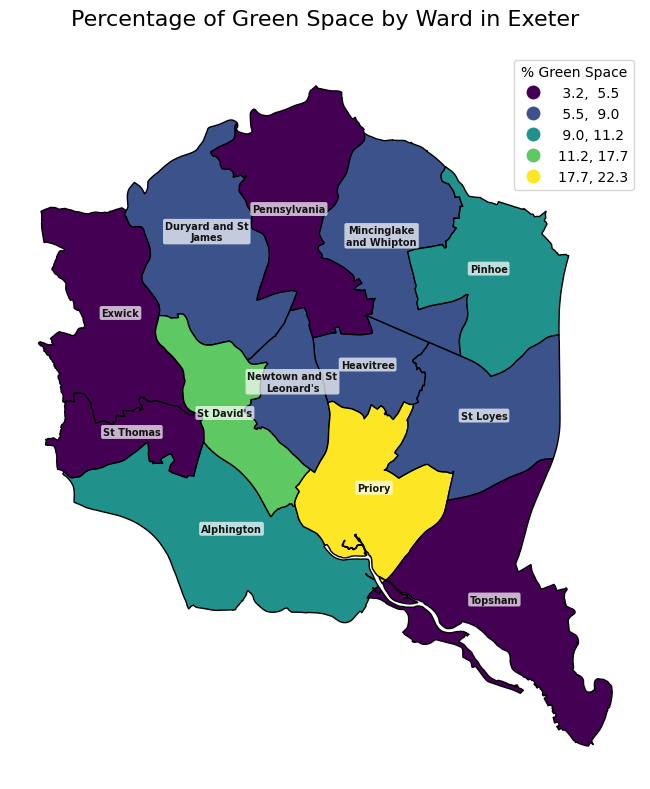

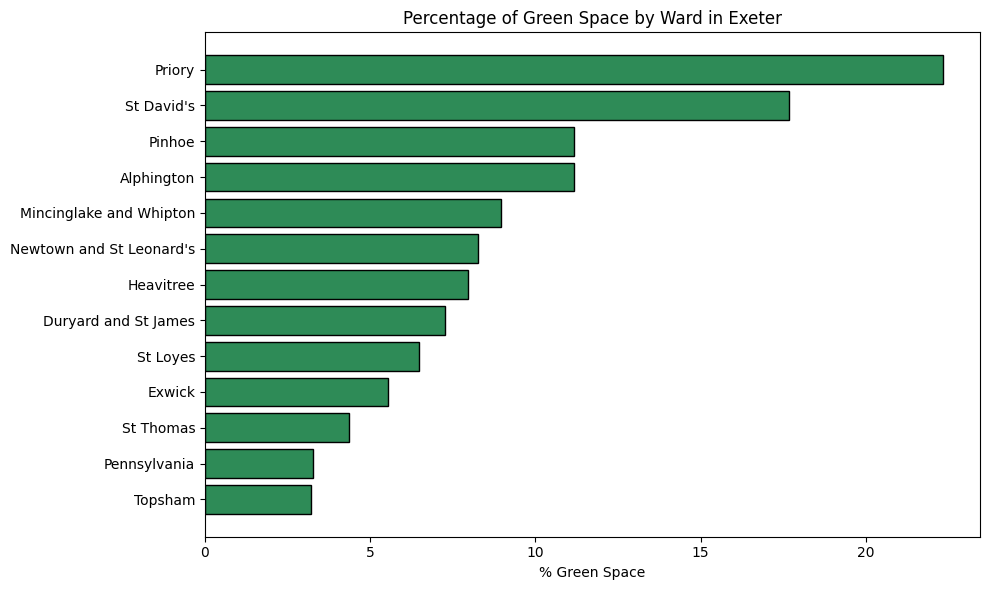

In [ ]:
# choropleth: percentage green space by ward (natural breaks)
ax = exeter.plot(
    column="pct_green",
    scheme="natural_breaks",
    k=5,
    cmap="viridis",
    legend=True,
    legend_kwds={"title": "% Green Space", "fmt": "{:.1f}"},
    figsize=(10, 8),
    edgecolor="black",
)
add_ward_labels(ax, exeter)
ax.set_title("Percentage of Green Space by Ward in Exeter", fontsize=16, pad=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

plot_bar(exeter, "pct_green", "% Green Space", "Percentage of Green Space by Ward in Exeter")

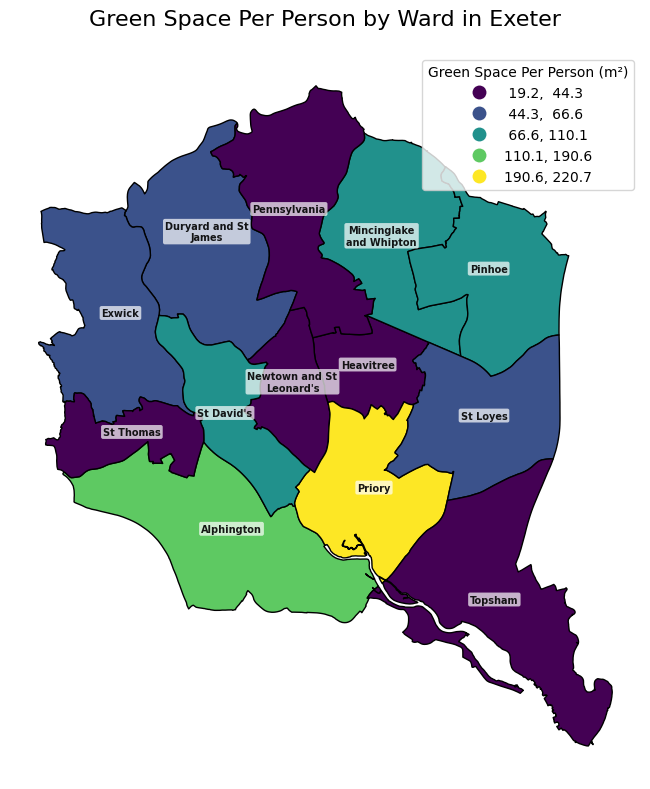

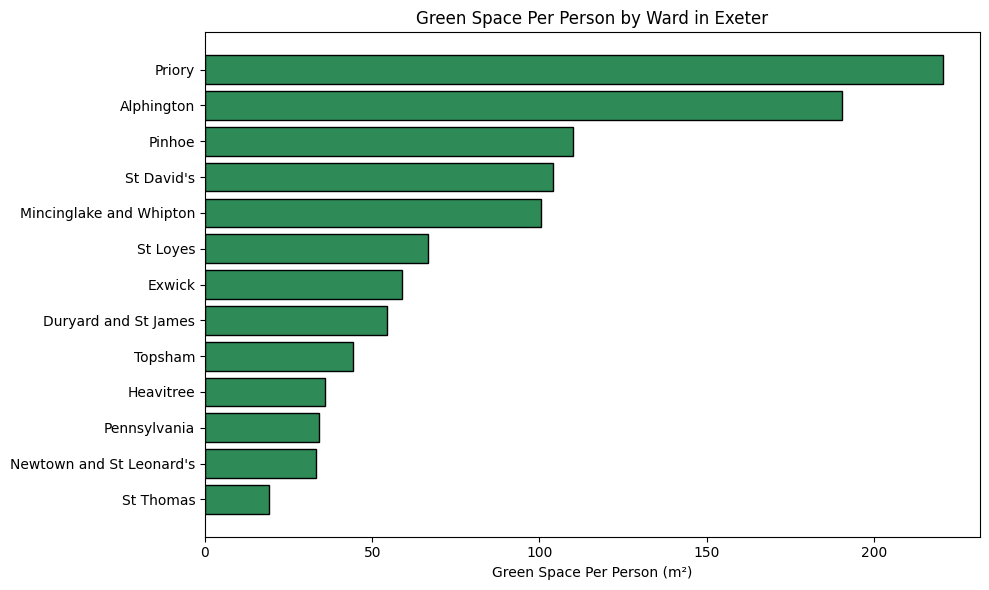

In [ ]:
# choropleth: green space per person by ward (natural breaks)
ax = exeter.plot(
    column="green_per_person",
    scheme="natural_breaks",
    k=5,
    cmap="viridis",
    legend=True,
    legend_kwds={"title": "Green Space Per Person (m²)", "fmt": "{:.1f}"},
    figsize=(10, 8),
    edgecolor="black",
)
add_ward_labels(ax, exeter)
ax.set_title("Green Space Per Person by Ward in Exeter", fontsize=16, pad=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

plot_bar(exeter, "green_per_person", "Green Space Per Person (m²)", "Green Space Per Person by Ward in Exeter")

## Green Space Density Heatmap

This heatmap shows the concentration and clustering of green spaces across Exeter, rather than just total area by ward. Areas with warmer colors (yellow/red) indicate higher density of green space features.

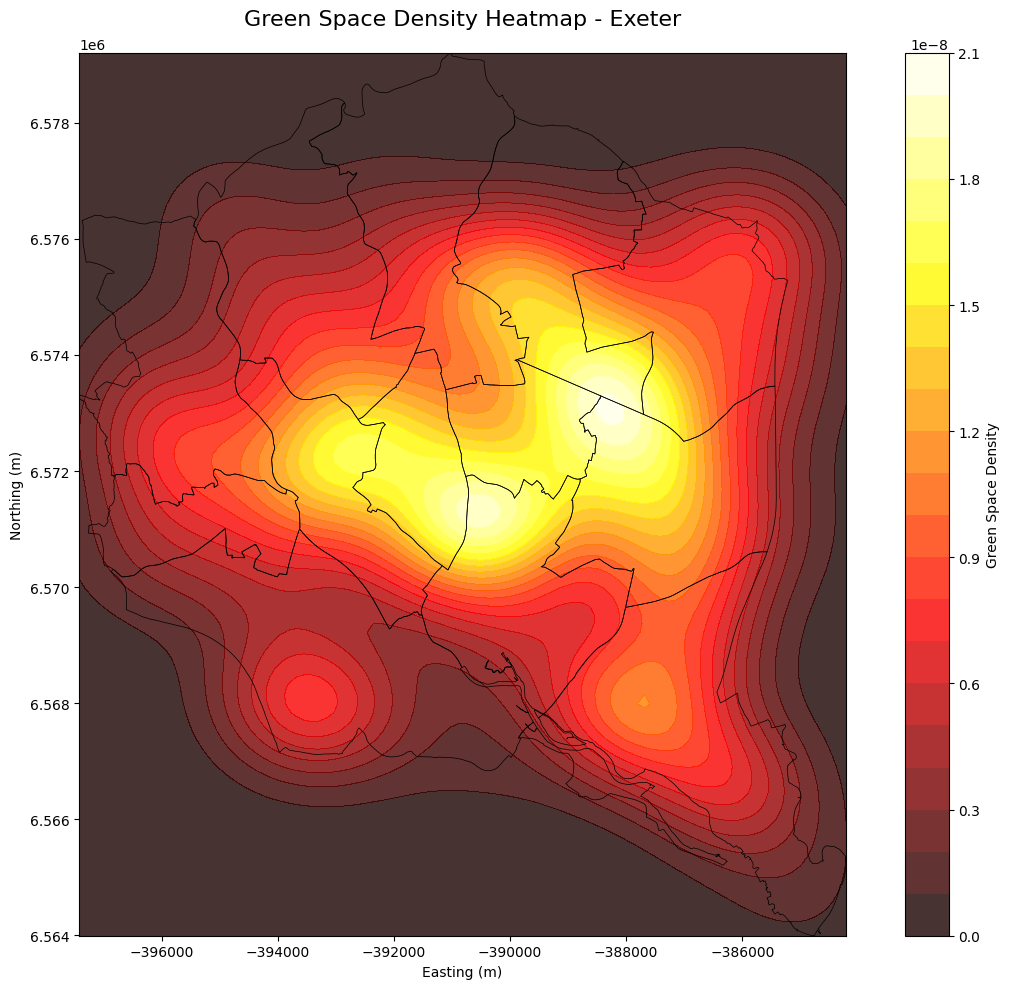

In [ ]:
# extract green space centroids and convert to Web Mercator for density calculation
green_centroids = green.copy()
green_centroids['geometry'] = green_centroids.geometry.centroid

# get x, y coordinates
x = np.array([geom.x for geom in green_centroids.geometry])
y = np.array([geom.y for geom in green_centroids.geometry])

# create a grid covering Exeter
minx, miny, maxx, maxy = exeter.total_bounds
grid_size = 100
grid_x = np.linspace(minx, maxx, grid_size)
grid_y = np.linspace(miny, maxy, grid_size)
xx, yy = np.meshgrid(grid_x, grid_y)

# reshape grid for KDE evaluation
positions = np.vstack([xx.ravel(), yy.ravel()])
kernel = gaussian_kde(np.vstack([x, y]))
density = kernel(positions).reshape(xx.shape)

# plot the heatmap
fig, ax = plt.subplots(figsize=(12, 10))
heatmap = ax.contourf(xx, yy, density, levels=20, cmap='hot', alpha=0.8)
exeter.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5)
plt.colorbar(heatmap, ax=ax, label='Green Space Density')
ax.set_title('Green Space Density Heatmap - Exeter', fontsize=16, pad=20)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
fig.tight_layout()
plt.show()

## Interactive Heatmap

Use the interactive map below to explore green space concentration. You can zoom and pan to see fine-grained clustering patterns.

In [ ]:
# reproject green centroids to WGS84 (latitude/longitude) for Folium
green_wgs84 = green_centroids.to_crs(4326)

# extract lat/lon pairs
heat_data = [[geom.y, geom.x] for geom in green_wgs84.geometry]

# create base map centered on Exeter
exeter_center = [50.7184, -3.5339]  # approximate center of Exeter
m = folium.Map(location=exeter_center, zoom_start=12, tiles='OpenStreetMap')

# add heatmap layer
HeatMap(heat_data, radius=25, blur=15, max_zoom=1).add_to(m)

# add ward boundaries as a reference
for _, row in exeter.to_crs(4326).iterrows():
    folium.GeoJson(
        data=row.geometry.__geo_interface__,
        style_function=lambda x: {'color': 'black', 'fillOpacity': 0.0, 'weight': 1}
    ).add_to(m)

m